# **ES 335 - Machine Learning Assignment 2**

# Importing Libraries and Modules

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Question 1

Implement the $k$-Nearest Neighbours (kNN) classifier and evaluate its performance on the `Social Network Ads.csv` dataset, which is a categorical dataset used to determine whether a user purchased a product or not based on three features.

* Visualize the data using a three-dimensional plot of the features, using different colors to represent class labels 0 and 1.

* Implement the kNN classifier from scratch and compare its performance with the available library implementation. Use 90% of the data for training and the remaining 10% for testing the classification accuracy.

* Using the confusion matrix, compute the accuracy, precision, recall, and F1-score for different values of $k$.

* Apply the $K$-fold cross-validation technique (assume $K$ = 5) and plot the average classification accuracy as a function of the number of neighbours $k$. Identify the value of $k$ that yields the best accuracy.

* For the optimal value of k obtained above, compare the classification performance using the following distance or similarity metrics:

    *    Euclidean distance

    * Cosine similarity

    *  Mahalanobis distance

    Identify the metric that gives the best performance.

* From the above experiments, study the effect of extreme values of k (such as $k$ = 1 and very large values of $k$). Infer the reasons behind the observed behavior. Repeat the experiment by fixing $k$ and reducing the amount of training data (e.g., 40% and 60% of the dataset) to examine whether the same value of $k$ performs well for different training set sizes.

* Effect of $k$: Visualize the decision boundaries by considering two features at a time for different values of $k$. Comment on which values of $k$ result in smoother decision boundaries.

* Regression: Implement kNN for regression by considering the first two features as input variables and the third feature as the output variable. Use a 60:40 train–test split and report the mean squared error (MSE) on the test data for different values of $k$.

**1(a) Visualising Data**

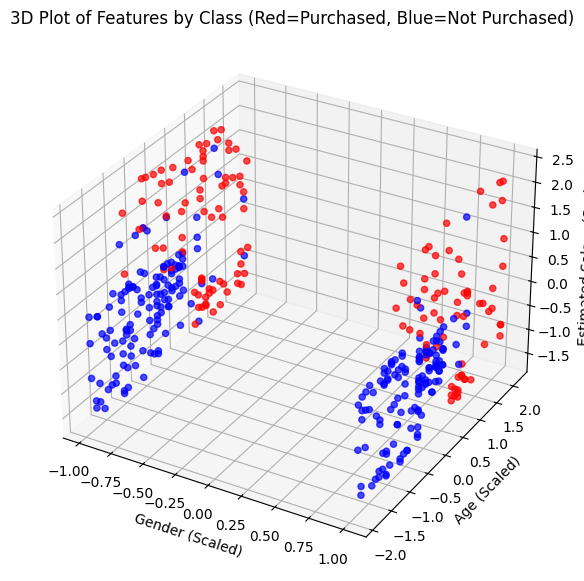

In [ ]:
# Loading and Preprocessing Data
df = pd.read_csv('/content/drive/MyDrive/MLCode/Dataset/Social_Network_Ads.csv')

if 'User ID' in df.columns:
    df = df.drop('User ID', axis=1)

# Encoding categorical feature 'Gender'
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Features (X) and target (y)
X = df[['Gender', 'Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Scaling features (Crucial for kNN to prevent EstimatedSalary from dominating)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 3D Visualization
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using different colors for class 0 and 1
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=y,cmap ='bwr', alpha=0.7)
ax.set_xlabel('Gender (Scaled)')
ax.set_ylabel('Age (Scaled)')
ax.set_zlabel('Estimated Salary (Scaled)')
plt.title('3D Plot of Features by Class (Red=Purchased, Blue=Not Purchased)')
plt.show()

**1(b) Implementing kNN**

In [ ]:
# Splitting data: 90% Train, 10% Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.10, random_state=42)

# Custom kNN Implementation
def euclidean_distance(a,b):
  return np.sqrt(np.sum((a-b)**2))

def knn_predict(X_train,y_train,x_test,k):
  distances = []

  for i in range(len(X_train)):
    dist = euclidean_distance(X_train[i],x_test)
    distances.append((dist,y_train[i]))

  distances.sort(key=lambda x:x[0])
  neighbors = distances[:k]
  labels = [label for _,label in neighbors]
  return Counter(labels).most_common(1)[0][0]

def knn_classifier(X_train,y_train,X_test,k):
    predictions = []
    for x in X_test:
        pred = knn_predict(X_train,y_train,x,k)
        predictions.append(pred)

    return np.array(predictions)


# Comparing Models (k=5)
k = 5
y_pred_custom = knn_classifier(X_train,y_train,X_test,k)
acc_custom = accuracy_score(y_test, y_pred_custom)

sklearn_knn = KNeighborsClassifier(n_neighbors=5)
sklearn_knn.fit(X_train, y_train)
y_pred_sklearn = sklearn_knn.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"Custom kNN Accuracy: {acc_custom:.4f}")
print(f"Library kNN Accuracy: {acc_sklearn:.4f}")

Custom kNN Accuracy: 0.9500
Library kNN Accuracy: 0.9500


**1(c) Accuracy using COnfusion Matrix**

Confusion Matrix for Custom kNN

In [ ]:
k_values = [3, 5, 7, 9, 11]

for k in k_values:
    y_pred = knn_classifier(X_train,y_train,X_test,k)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"k = {k}")
    print(f"Confusion Matrix:\n {cm}")
    print(f"Accuracy: {acc:.2f} | Precision: {prec:.2f} | Recall: {rec:.2f} | F1: {f1:.2f}")

k = 3
Confusion Matrix:
 [[25  2]
 [ 1 12]]
Accuracy: 0.93 | Precision: 0.86 | Recall: 0.92 | F1: 0.89
k = 5
Confusion Matrix:
 [[25  2]
 [ 0 13]]
Accuracy: 0.95 | Precision: 0.87 | Recall: 1.00 | F1: 0.93
k = 7
Confusion Matrix:
 [[25  2]
 [ 0 13]]
Accuracy: 0.95 | Precision: 0.87 | Recall: 1.00 | F1: 0.93
k = 9
Confusion Matrix:
 [[25  2]
 [ 0 13]]
Accuracy: 0.95 | Precision: 0.87 | Recall: 1.00 | F1: 0.93
k = 11
Confusion Matrix:
 [[25  2]
 [ 0 13]]
Accuracy: 0.95 | Precision: 0.87 | Recall: 1.00 | F1: 0.93


Confusion Matrix for Sklearn kNN

In [ ]:
k_values = [3, 5, 7, 9, 11]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"k = {k}")
    print(f"Confusion Matrix:\n {cm}")
    print(f"Accuracy: {acc:.2f} | Precision: {prec:.2f} | Recall: {rec:.2f} | F1: {f1:.2f}")

k = 3
Confusion Matrix:
 [[25  2]
 [ 1 12]]
Accuracy: 0.93 | Precision: 0.86 | Recall: 0.92 | F1: 0.89
k = 5
Confusion Matrix:
 [[25  2]
 [ 0 13]]
Accuracy: 0.95 | Precision: 0.87 | Recall: 1.00 | F1: 0.93
k = 7
Confusion Matrix:
 [[25  2]
 [ 0 13]]
Accuracy: 0.95 | Precision: 0.87 | Recall: 1.00 | F1: 0.93
k = 9
Confusion Matrix:
 [[25  2]
 [ 0 13]]
Accuracy: 0.95 | Precision: 0.87 | Recall: 1.00 | F1: 0.93
k = 11
Confusion Matrix:
 [[25  2]
 [ 0 13]]
Accuracy: 0.95 | Precision: 0.87 | Recall: 1.00 | F1: 0.93


Graph of Accuracy vs k

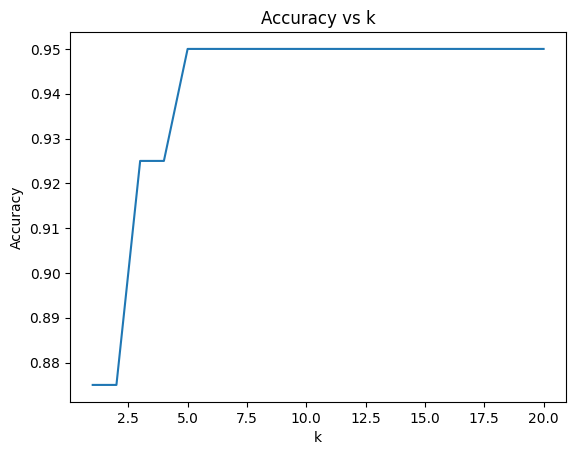

In [ ]:
k_values = range(1,21)

accuracy_list = []

for k in k_values:
    pred = knn_classifier(X_train,y_train,X_test,k)

    acc = accuracy_score(y_test,pred)

    accuracy_list.append(acc)

plt.plot(k_values,accuracy_list)

plt.xlabel("k")
plt.ylabel("Accuracy")

plt.title("Accuracy vs k")

plt.show()

**1(d) K-fold Cross validation**

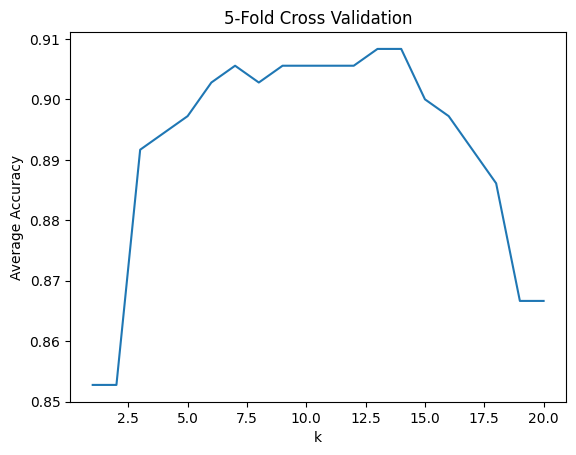

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

k_values = range(1,21)

cv_accuracy = []

for k in k_values:

    fold_scores = []

    for train_index, test_index in kf.split(X_train):

        X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
        y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

        pred = knn_classifier(X_train_cv,y_train_cv,X_test_cv,k)

        acc = accuracy_score(y_test_cv,pred)

        fold_scores.append(acc)

    cv_accuracy.append(np.mean(fold_scores))

plt.plot(k_values, cv_accuracy)

plt.xlabel("k")
plt.ylabel("Average Accuracy")

plt.title("5-Fold Cross Validation")

plt.show()

In [ ]:
optimal_k = k_values[np.argmax(cv_accuracy)]

print("Optimal value of k:", optimal_k)

Optimal value of k: 13


**1(e) Comparing Distance Metrics**

In [ ]:
def cosine_distance(a,b):
    return 1 - np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))

# For Mahalanobis Distance we need Covariance matrix
cov_matrix = np.cov(X_train.T)
inv_cov = np.linalg.inv(cov_matrix)

def mahalanobis_distance(a,b):
    diff = a-b
    return np.sqrt(diff.T @ inv_cov @ diff)

def knn_predict_metric(X_train,y_train,x_test,k,metric):
    distances=[]

    for i in range(len(X_train)):
        if metric=="euclidean":
            dist = euclidean_distance(X_train[i],x_test)

        elif metric=="cosine":
            dist = cosine_distance(X_train[i],x_test)

        elif metric=="mahalanobis":
            dist = mahalanobis_distance(X_train[i],x_test)

        distances.append((dist,y_train[i]))

    distances.sort(key=lambda x:x[0])

    neighbors = distances[:k]

    labels=[label for _,label in neighbors]

    return Counter(labels).most_common(1)[0][0]

metrics = ["euclidean","cosine","mahalanobis"]

for m in metrics:
    preds=[]

    for x in X_test:
        preds.append(knn_predict_metric(X_train,y_train,x,best_k,m))

    preds=np.array(preds)
    acc=accuracy_score(y_test,preds)
    print(f"Accuracy using {m} distance:{acc}")

Accuracy using euclidean distance:0.95
Accuracy using cosine distance:0.95
Accuracy using mahalanobis distance:0.95


**1(f) Extreme Values of $k$ and Training Sizes**

In [ ]:
N= X_train.shape[0]
for k in [1,5,10,50,100, N]:

    pred = knn_classifier(X_train,y_train,X_test,k)

    acc = accuracy_score(y_test,pred)

    print(f"Accuracy when (k={k}): {acc}")

Accuracy when (k=1): 0.875
Accuracy when (k=5): 0.95
Accuracy when (k=10): 0.95
Accuracy when (k=50): 0.925
Accuracy when (k=100): 0.775
Accuracy when (k=360): 0.675


$k=1$ (Too small): The model is highly sensitive to noise and outliers in the training data. This leads to overfitting (high variance, low bias). It memorizes the training data but fails to generalize.

Large $k$ (e.g., $k=N$): The model will simply predict the majority class of the entire dataset regardless of the input. This leads to underfitting (high bias, low variance). It oversimplifies the problem.

In [ ]:
# Testing with different training sizes
sizes = [0.4, 0.6]
optimal_k = 13

for size in sizes:
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, train_size=size, random_state=42)
    pred = knn_classifier(X_tr,y_tr,X_te,optimal_k)
    print(f"Accuracy with {int(size*100)}% training data (k={optimal_k}): {accuracy_score(y_te, knn.predict(X_te)):.4f}")

Accuracy with 40% training data (k=13): 0.6208
Accuracy with 60% training data (k=13): 0.6250


**1(g) Visualising Decision Boundary**

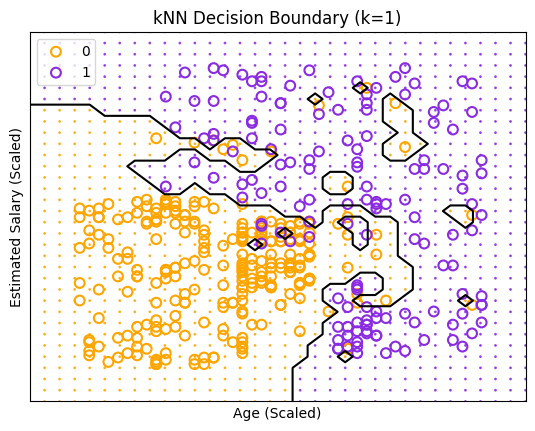

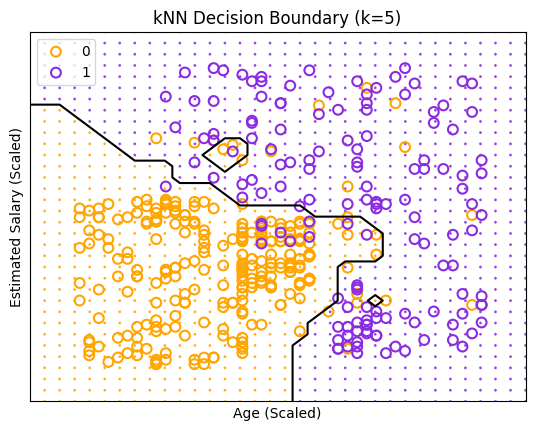

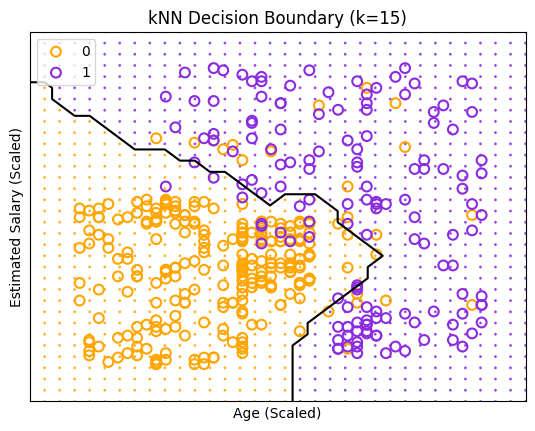

In [ ]:
from matplotlib.colors import ListedColormap

# Cosidering only Age and EstimatedSalary for 2D visualization
X_2d = df[['Age', 'EstimatedSalary']].values
X_2d_scaled = StandardScaler().fit_transform(X_2d)

def plot_decision_boundary(k_val):
    knn_2d = KNeighborsClassifier(n_neighbors=k_val)
    knn_2d.fit(X_2d_scaled, y)

    # Creating meshgrid
    X_set, y_set = X_2d_scaled, y
    X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 0.5, stop=X_set[:, 0].max() + 0.5, step=0.15),
                        np.arange(start=X_set[:, 1].min() - 0.5, stop=X_set[:, 1].max() + 0.5, step=0.15))

    # Get predictions for the entire grid
    Z = knn_2d.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)


    # Mapping 0 to 'orange' and 1 to 'blueviolet'
    Z_flat = Z.ravel()
    dot_colors = np.where(Z_flat == 0, 'orange', 'blueviolet')
    plt.scatter(X1.ravel(), X2.ravel(), c=dot_colors, s=1, alpha=0.8)

    #Drawing the black decision boundary line
    plt.contour(X1, X2, Z, levels=[0.5], colors='black', linewidths=1.5)

    # Plotting the actual data points as hollow circles
    colors = ['orange', 'blueviolet']
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    facecolors='none', edgecolors=colors[i],
                    s=50, linewidths=1.5, label=j)

    plt.title(f'kNN Decision Boundary (k={k_val})')
    plt.xlabel('Age (Scaled)')
    plt.ylabel('Estimated Salary (Scaled)')
    plt.legend()
    plt.xticks([])
    plt.yticks([])

    plt.show()


# Visualizing for k=1 (jagged) and k=15 (smoother)
plot_decision_boundary(1)
plot_decision_boundary(5)
plot_decision_boundary(15)

**Note: Some assistance from AI tools was taken for plotting**

Higher values of $k$ result in smoother decision boundaries. When $k=1$, the boundary tightly wraps around individual data points (jagged), indicating overfitting. As $k$ increases, the algorithm looks at more neighbors, effectively "averaging out" the noise and creating a smoother, more generalized division between classes.

**1(h) $k$NN for Regression**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Features: Gender, Age and Target: EstimatedSalary
X_reg = df[['Gender', 'Age']].values
y_reg = df['EstimatedSalary'].values

# Scaling inputs
X_reg_scaled = StandardScaler().fit_transform(X_reg)

# 60:40 Train-Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_scaled, y_reg, test_size=0.40, random_state=42)

k_regression_values = [3, 5, 7, 9, 11]

for k in k_regression_values:
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_train_r, y_train_r)
    y_pred_r = knn_reg.predict(X_test_r)

    mse = mean_squared_error(y_test_r, y_pred_r)
    print(f"k={k} | Mean Squared Error (MSE): {mse:.2f}")

k=3 | Mean Squared Error (MSE): 1665320833.33
k=5 | Mean Squared Error (MSE): 1495118750.00
k=7 | Mean Squared Error (MSE): 1350705357.14
k=9 | Mean Squared Error (MSE): 1257785185.19
k=11 | Mean Squared Error (MSE): 1241035950.41


# Question 2

Perform binary classification using logistic regression on the dataset `Social Network Ads.csv`,
which is a categorical dataset used to determine whether a user purchased a product or not based on
three features.

1. Visualize the data by plotting the features in a three-dimensional space, using different colors to
represent class labels 0 and 1.
2. Implement the logistic (sigmoid) function and learn the model parameters using the following
optimization methods:
    * Stochastic gradient descent.
    * Newton’s method (iteratively reweighted least squares method). Examine whether the IRLS method converges in fewer iterations compared to gradient descent.
    * An available library implementation. Compare the results with the above methods.

3. Plot the training data, test data, and the decision boundary learned by logistic regression in
the same figure. The decision boundary should be a straight line separating the region where
$h_w(x)$ > 0.5 from the region where $h_w(x)$ ≤ 0.5, where

$$ h_w(x^{(i)}) = σ(w^⊤x^{(i)})$$

Use 90% of the data for training and the remaining 10% for testing the classification performance.
Using the confusion matrix, compute the accuracy, precision, recall, and F1-score for each method.

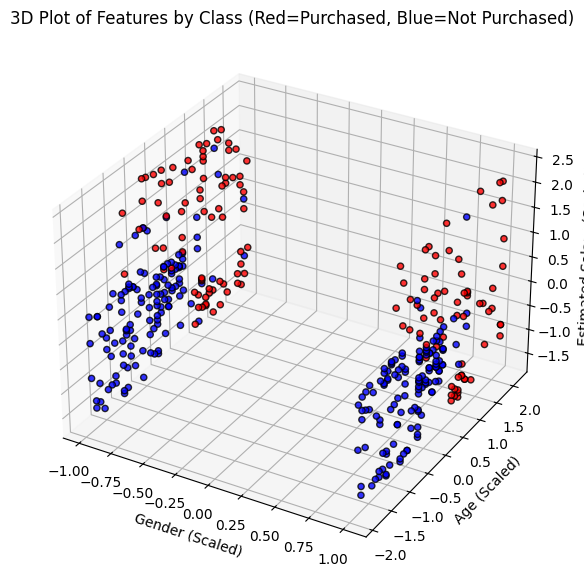

In [ ]:
# Loading the dataset
df = pd.read_csv('/content/drive/MyDrive/MLCode/Dataset/Social_Network_Ads.csv')

if 'User ID' in df.columns:
    df = df.drop('User ID', axis=1)

# Encoding Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

X = df[['Gender', 'Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Scaling features (essential for gradient descent convergence)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualizing 3D Data
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot: color-coded by class label
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
                     c=y, cmap='bwr', alpha=0.8, edgecolors='k')
ax.set_xlabel('Gender (Scaled)')
ax.set_ylabel('Age (Scaled)')
ax.set_zlabel('Estimated Salary (Scaled)')
plt.title('3D Plot of Features by Class (Red=Purchased, Blue=Not Purchased)')
plt.show()

**2(b) Implementing Logistic Regression and Optimization Methods**

We need to add a column of ones to our feature matrix to account for the bias term ($w_0$) in our manual implementations. Then, we implement the sigmoid function, SGD, and IRLS.

In [ ]:
# Adding bias term (column of 1s) to X for scratch implementations
X_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

# 90% Training, 10% Testing Split
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.10, random_state=42)


def sigmoid(z):
    z = np.clip(z, -250, 250)
    return 1 / (1 + np.exp(-z))

# Method A: Stochastic Gradient Descent (SGD)
np.random.seed(42)
w_sgd = np.zeros(X_train.shape[1])
learning_rate = 0.01
epochs = 100

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train))
    X_tr_shuffled = X_train[indices]
    y_tr_shuffled = y_train[indices]

    for i in range(len(X_tr_shuffled)):
        xi = X_tr_shuffled[i]
        yi = y_tr_shuffled[i]
        prediction = sigmoid(np.dot(xi, w_sgd))
        # Update weights: w = w - learning_rate * gradient
        w_sgd -= learning_rate * (prediction - yi) * xi


# Method B: Newton's Method (Iteratively Reweighted Least Squares - IRLS)
w_irls = np.zeros(X_train.shape[1])
irls_iterations = 10

for i in range(irls_iterations):
    predictions = sigmoid(np.dot(X_train, w_irls))

    # Diagonal weight matrix S: S_ii = h(x_i) * (1 - h(x_i))
    # Add a small epsilon to prevent singular matrix issues
    S = np.diag(predictions * (1 - predictions) + 1e-5)

    # Gradient: X.T * (Predictions - y)
    gradient = np.dot(X_train.T, (predictions - y_train))

    # Hessian: X.T * S * X
    hessian = np.dot(X_train.T, np.dot(S, X_train))

    # Weight update: w = w - Inverse(Hessian) * Gradient
    w_irls -= np.linalg.pinv(hessian).dot(gradient)


# Method C: Library Implementation (scikit-learn)
sklearn_lr = LogisticRegression(solver='lbfgs')
sklearn_lr.fit(X_train[:, 1:], y_train)

LogisticRegression()

In [ ]:
def evaluate_model(w, X_t, y_t, model_name, is_sklearn=False):
    if is_sklearn:
        y_pred = w.predict(X_t[:, 1:]) # Sklearn handles bias
    else:
        y_pred_prob = sigmoid(np.dot(X_t, w))
        y_pred = (y_pred_prob > 0.5).astype(int)

    cm = confusion_matrix(y_t, y_pred)
    acc = accuracy_score(y_t, y_pred)
    prec = precision_score(y_t, y_pred, zero_division=0)
    rec = recall_score(y_t, y_pred, zero_division=0)
    f1 = f1_score(y_t, y_pred, zero_division=0)

    print(f"{model_name}")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}\n")

evaluate_model(w_sgd, X_test, y_test, "Stochastic Gradient Descent (SGD)")
evaluate_model(w_irls, X_test, y_test, "Newton's Method (IRLS)")
evaluate_model(sklearn_lr, X_test, y_test, "Sklearn Library Implementation", is_sklearn=True)

Stochastic Gradient Descent (SGD)
Confusion Matrix:
 [[25  2]
 [ 2 11]]
Accuracy: 0.9000 | Precision: 0.8462 | Recall: 0.8462 | F1-Score: 0.8462

Newton's Method (IRLS)
Confusion Matrix:
 [[25  2]
 [ 2 11]]
Accuracy: 0.9000 | Precision: 0.8462 | Recall: 0.8462 | F1-Score: 0.8462

Sklearn Library Implementation
Confusion Matrix:
 [[25  2]
 [ 2 11]]
Accuracy: 0.9000 | Precision: 0.8462 | Recall: 0.8462 | F1-Score: 0.8462



**2(c)Plotting the 2D Decision Boundary**

Because plotting a straight line decision boundary is best visualized in 2D, we will focus the decision boundary plot on the two continuous features (Age and EstimatedSalary). The line equation derives from $w_0 + w_1 x_1 + w_2 x_2 = 0$, leading to $x_2 = -(w_0 + w_1 x_1) / w_2$.

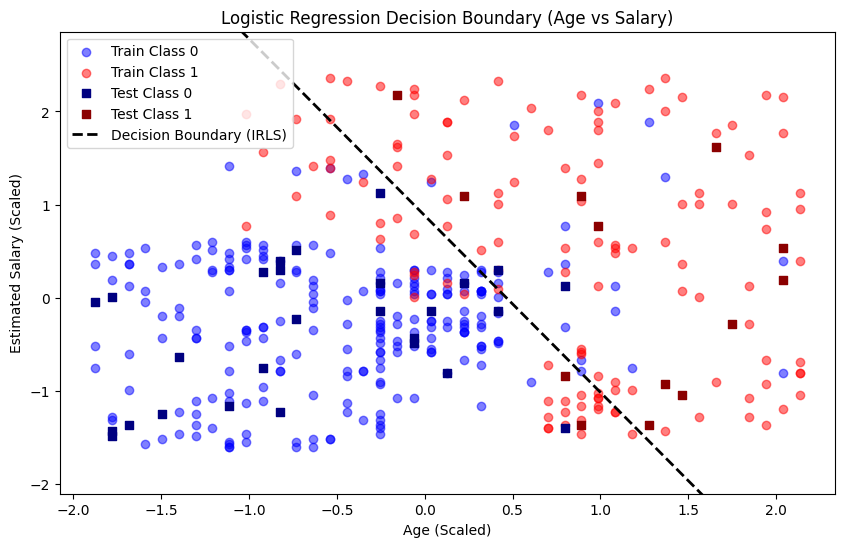

In [ ]:
# For visual clarity of a "straight line" decision boundary,
# we visualize it on the two continuous features: Age (index 1) and Salary (index 2).
# We assume Gender is set to 0 (mean scaled value) to collapse the 3D plane to a 2D line.

plt.figure(figsize=(10, 6))

# Plotting train data
plt.scatter(X_train[y_train == 0][:, 2], X_train[y_train == 0][:, 3], color='blue', label='Train Class 0', alpha=0.5)
plt.scatter(X_train[y_train == 1][:, 2], X_train[y_train == 1][:, 3], color='red', label='Train Class 1', alpha=0.5)

# Plotting test data
plt.scatter(X_test[y_test == 0][:, 2], X_test[y_test == 0][:, 3], color='navy', marker='s', label='Test Class 0')
plt.scatter(X_test[y_test == 1][:, 2], X_test[y_test == 1][:, 3], color='darkred', marker='s', label='Test Class 1')

# Calculating the decision boundary using weights from IRLS
# Equation: w0 + w1*Gender + w2*Age + w3*Salary = 0
# We fix Gender (x[:, 1]) to 0 to see the line on the Age vs Salary plane
w0, w1, w2, w3 = w_irls
x2_boundary = np.array([X_scaled[:, 1].min(), X_scaled[:, 1].max()])
# Derived from w0 + w1(0) + w2*Age + w3*Salary = 0  => Salary = -(w0 + w2*Age)/w3
x3_boundary = -(w0 + w2 * x2_boundary) / w3

plt.plot(x2_boundary, x3_boundary, color='black', linestyle='--', linewidth=2, label='Decision Boundary (IRLS)')

plt.xlabel('Age (Scaled)')
plt.ylabel('Estimated Salary (Scaled)')
plt.title('Logistic Regression Decision Boundary (Age vs Salary)')
plt.legend()
plt.ylim(X_scaled[:, 2].min() - 0.5, X_scaled[:, 2].max() + 0.5)
plt.show()

**Note: Some assistance from AI tools was taken for plotting.**

# Question 3

An imbalanced dataset refers to a dataset in which the classes are not represented equally. Classifi-
cation problems involving multiple classes with imbalanced data present additional challenges compared

to binary classification. A skewed class distribution often reduces the effectiveness of machine learning
algorithms, particularly in predicting samples from minority classes.
In this question, you will perform multiclass logistic regression (softmax classification) on the 20
Newsgroups dataset (available at https://www.kaggle.com/datasets/crawford/20-newsgroups).
1. Since the original dataset is balanced, preprocess the data to create an imbalanced version by
removing a subset of news articles from selected classes. An example of such an imbalance is
shown in the dataset description.
2. Perform multiclass classification using logistic regression on both the balanced and imbalanced
versions of the dataset.
3. Evaluate and compare the performance of the classifier in each case by computing the confusion
matrix and classification accuracy.
4. You may refer to the following resource for a better understanding of multiclass logistic regression
implemented from scratch:
https://towardsdatascience.com/multiclass-logistic-regression-from-scratch-9cc0007da372

**Loading the Data and Preprocessing**

Machine learning models cannot process raw text directly. Therefore, we have to convert the text documents into numerical vectors

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

# Loading the 20 Newsgroups dataset
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

# Extracting text and labels
X_train_text, y_train_bal = newsgroups_train.data, newsgroups_train.target
X_test_text, y_test = newsgroups_test.data, newsgroups_test.target
target_names = newsgroups_train.target_names

# Convert Text to Numerical Features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_bal = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"Original Balanced Training Data Shape: {X_train_bal.shape}")

Original Balanced Training Data Shape: (11314, 5000)


**Creating the Imbalanced Dataset**

In [ ]:
# Creating the Imbalanced version
# Defined which classes to downsample, and the retention rate (e.g., keep 5%)
classes_to_downsample = [0, 1, 2, 3, 4]
retention_rate = 0.05

indices_to_keep = []

for class_idx in range(len(target_names)):
    # Find all indices for the current class
    class_indices = np.where(y_train_bal == class_idx)[0]

    if class_idx in classes_to_downsample:
        np.random.seed(42)
        np.random.shuffle(class_indices)
        num_to_keep = int(len(class_indices) * retention_rate)
        indices_to_keep.extend(class_indices[:num_to_keep])
    else:
        indices_to_keep.extend(class_indices)

# Filtering the training data to create the imbalanced set
indices_to_keep = np.array(indices_to_keep)
X_train_imb = X_train_bal[indices_to_keep]
y_train_imb = y_train_bal[indices_to_keep]

print(f"Imbalanced Training Data Shape: {X_train_imb.shape}")

Imbalanced Training Data Shape: (8630, 5000)


**Training the Multiclass Logistic Regression Models**

In [ ]:
# Performing Multiclass Logistic Regression
clf_balanced = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
clf_imbalanced = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

# Train on the Balanced Dataset
print("\nTraining model on Balanced Dataset..")
clf_balanced.fit(X_train_bal, y_train_bal)

# Train on the Imbalanced Dataset
print("Training model on Imbalanced Dataset..")
clf_imbalanced.fit(X_train_imb, y_train_imb)


Training model on Balanced Dataset..
Training model on Imbalanced Dataset..


LogisticRegression(max_iter=1000, random_state=42)

**Evaluating and Comparing Performance**


Results
Accuracy (Balanced Model):   64.83%
Accuracy (Imbalanced Model): 52.85%


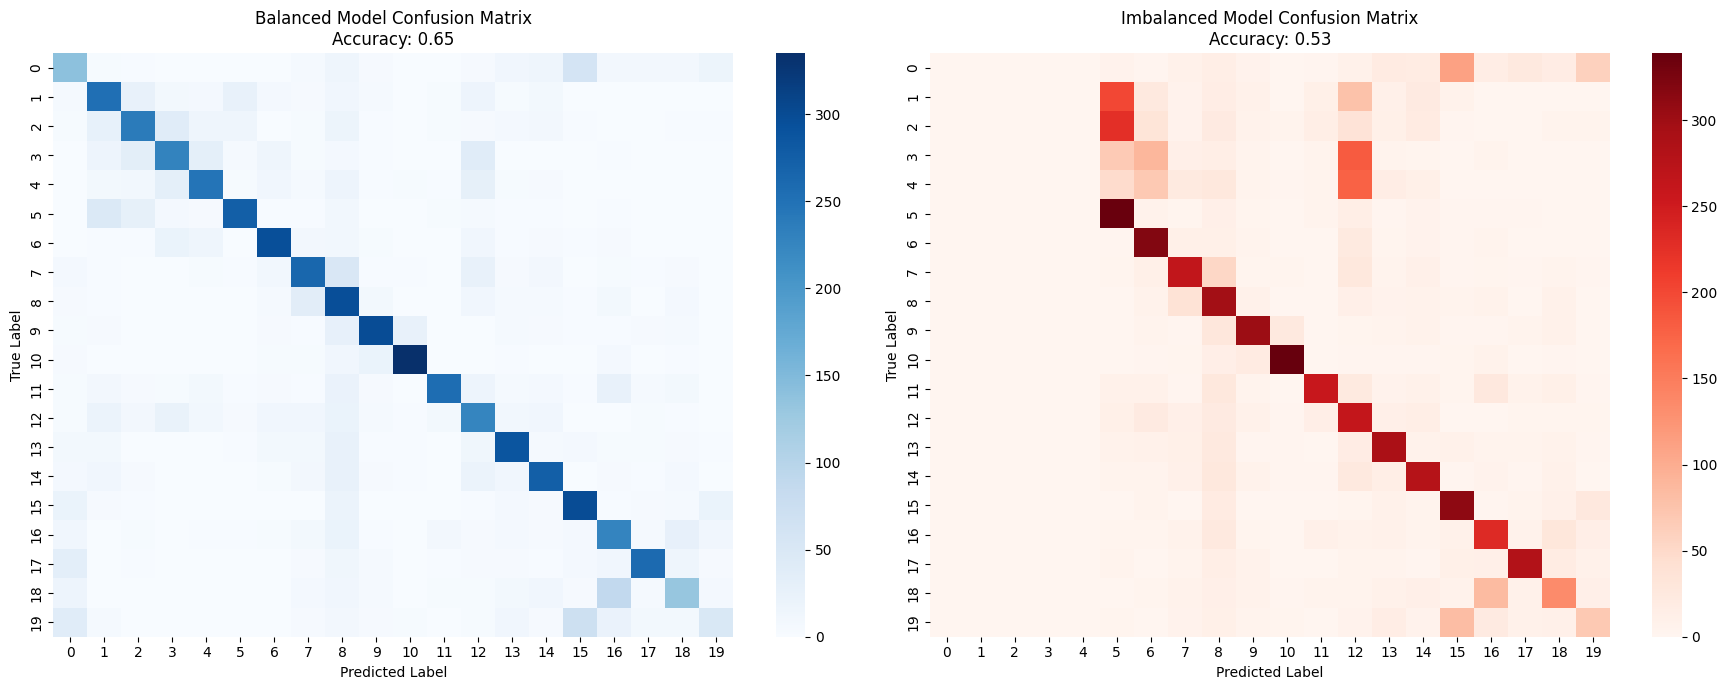


Classification Report (Imbalanced Model):
                          precision    recall  f1-score   support

             alt.atheism       0.00      0.00      0.00       319
           comp.graphics       0.00      0.00      0.00       389
 comp.os.ms-windows.misc       0.00      0.00      0.00       394
comp.sys.ibm.pc.hardware       0.00      0.00      0.00       392
   comp.sys.mac.hardware       0.00      0.00      0.00       385
          comp.windows.x       0.36      0.85      0.51       395
            misc.forsale       0.51      0.82      0.63       390
               rec.autos       0.61      0.67      0.64       396
         rec.motorcycles       0.43      0.75      0.54       398
      rec.sport.baseball       0.73      0.76      0.75       397
        rec.sport.hockey       0.87      0.85      0.86       399
               sci.crypt       0.77      0.65      0.71       396
         sci.electronics       0.29      0.67      0.40       393
                 sci.med       0

In [ ]:
# Evaluating and Comparing Performance

# Predictions
y_pred_bal = clf_balanced.predict(X_test)
y_pred_imb = clf_imbalanced.predict(X_test)

# Accuracy
acc_bal = accuracy_score(y_test, y_pred_bal)
acc_imb = accuracy_score(y_test, y_pred_imb)

print(f"\nResults")
print(f"Accuracy (Balanced Model):   {acc_bal * 100:.2f}%")
print(f"Accuracy (Imbalanced Model): {acc_imb * 100:.2f}%")

# Plotting Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Confusion Matrix for Balanced
cm_bal = confusion_matrix(y_test, y_pred_bal)
sns.heatmap(cm_bal, annot=False, cmap="Blues", ax=axes[0])
axes[0].set_title(f'Balanced Model Confusion Matrix\nAccuracy: {acc_bal:.2f}')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix for Imbalanced
cm_imb = confusion_matrix(y_test, y_pred_imb)
sns.heatmap(cm_imb, annot=False, cmap="Reds", ax=axes[1])
axes[1].set_title(f'Imbalanced Model Confusion Matrix\nAccuracy: {acc_imb:.2f}')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Detailed Classification Report for the Imbalanced Model
print("\nClassification Report (Imbalanced Model):")
# Notice how the recall and f1-score for classes 0, 1, 2, 3, and 4 drop significantly
print(classification_report(y_test, y_pred_imb, target_names=target_names, zero_division=0))

**Note: Some assistant from AI tools has been taken for plotting and structuring purpose.**

**Accuracy Drop:** The overall accuracy of the imbalanced model is lower than the balanced model.

**Confusion Matrix Bias:** The "Reds" heatmap (imbalanced), there is very dark vertical bands for the majority classes, and very pale/empty columns for indices 0 through 4. This means the model almost never predicts the minority classes and misclassifies them as one of the majority classes.

**Classification Report Metrics:** In the classification report output(Recall and F1-Score) for the first five classes (the ones we downsampled), the metrics dropped dramatically compared to the other 15 classes, practically proving the theoretical drawback of skewed class distributions.

# Question 4

Q4. Given a set of face images from the ORL face database, use Principal Component Analysis (PCA) to perform dimensionality reduction. You may use inbuilt functions for computing the principal components. Perform the following steps:

1. Use the ORL database consisting of $N$ = 400 face images of size 112 × 92, resulting in a data
matrix $X$ ∈ $R^{10304×400}$. Display a few face images to visualize the dataset.
2. Mean-subtract the data and compute the sample covariance matrix $S$ ∈ $R^{400×400}$.

3. Perform eigendecomposition of the covariance matrix S to obtain the matrix $U$, where each column of $U$ corresponds to an eigenvector.
4. Each eigenvector represents an eigenface. Reshape each eigenvector to match the original image size and visualize the eigenfaces for $k = 1, 100, . . . , D$.

5. Plot the variance explained by the principal components as a function of the component index $k$, where $k$ = 1 corresponds to the eigenvector with the highest variance. Consider $k = 1, 100, . . . , D$.

6. Use the first k eigenvectors (principal components) to obtain the low-dimensional representation
of the data:$$V = U^TX.$$

    Vary $k$ from 1 to D in steps of 100.

7. Compute the reconstruction error between the original data $X$ and the reconstructed data $X$
using the Frobenius norm (or matrix norm), defined as the square root of the sum of squared reconstruction errors.
8. Plot the reconstruction error as a function of the number of principal components $k$. Consider
$k = 1, 100, . . . , D.$
9. Visualize the reconstructed face images and compare them with the original images.
10. Determine the most suitable value of $k$. Report the corresponding reconstruction error and loss in
variance. Display 10 original face images along with their corresponding reconstructed images for
the selected value of $k$.

**Loading Data and Visualizing**

Data matrix X shape: (10304, 400)
Visualizing Original Faces


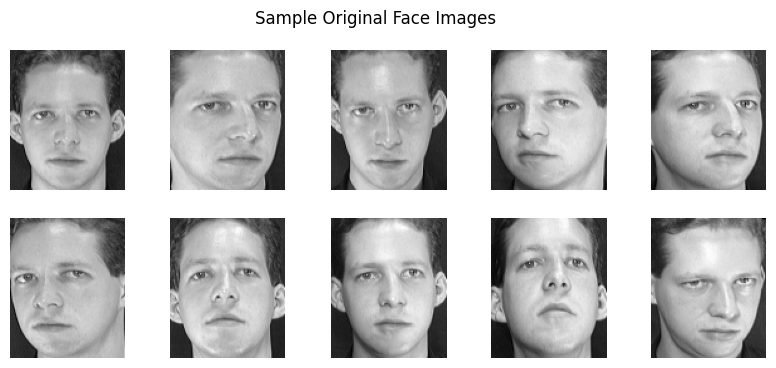

In [ ]:
import os
from PIL import Image

dataset_path = '/content/drive/MyDrive/MLCode/Dataset/ORL_dataset'

faces = []

# Looping through all 40 subjects and their 10 images
for subject in range(1, 41):
    for image_num in range(1, 11):
        img_path = os.path.join(dataset_path, f's{subject}', f'{image_num}.pgm')

        # Open the image, ensure it is grayscale ('L'), and convert to numpy array
        img = Image.open(img_path).convert('L')
        img_array = np.array(img)

        # Flatten the 112x92 image into a 10304 1D array
        faces.append(img_array.flatten())

# Converting to numpy array and transposing to get the required X shape: 10304 x 400
X = np.array(faces).T

print(f"Data matrix X shape: {X.shape}")
D = X.shape[1] # D = 400

def plot_faces(images, title, n_rows=2, n_cols=5):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4))
    for i, ax in enumerate(axes.flat):
        # Images are 112x92. Reshape and plot.
        ax.imshow(images[:, i].reshape(112, 92), cmap='gray')
        ax.axis('off')
    plt.suptitle(title)
    plt.show()

print("Visualizing Original Faces")
plot_faces(X, "Sample Original Face Images")


**Mean-subtract and Sample Covariance**

In [ ]:
mean_face = np.mean(X, axis=1, keepdims=True)

# Mean subtraction
X_centered = X - mean_face

# Compute Covariance Matrix S (400 x 400)
# To get a 400x400 matrix, we use the Eigenface trick: S = X^T * X
S = np.dot(X_centered.T, X_centered) / (D-1)

**Eigendecomposition**

In [ ]:
# Eigenvectors of S are 400x400
eigenvalues_S, eigenvectors_S = np.linalg.eigh(S)

# Sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigenvalues_S)[::-1]
eigenvalues_S = eigenvalues_S[idx]
eigenvectors_S = eigenvectors_S[:, idx]

# True eigenvectors (Eigenfaces) U = X_centered * eigenvectors_S
U = np.dot(X_centered, eigenvectors_S)

# Normalize the eigenvectors in U
U = U / np.linalg.norm(U, axis=0)

**Visualize Eigenfaces for specific k**

Visualizing Eigenfaces


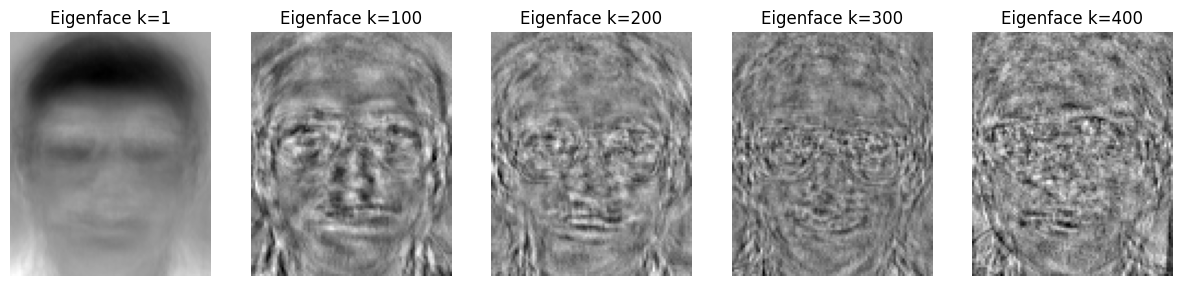

In [ ]:
k_visualize = [1, 100, 200, 300, 400] # Examples of k up to D
eigenfaces_to_plot = U[:, [k-1 for k in k_visualize]]

print("Visualizing Eigenfaces")
fig, axes = plt.subplots(1, len(k_visualize), figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.imshow(eigenfaces_to_plot[:, i].reshape(112, 92), cmap='gray')
    ax.set_title(f'Eigenface k={k_visualize[i]}')
    ax.axis('off')
plt.show()

**Plotting Variance Explained**

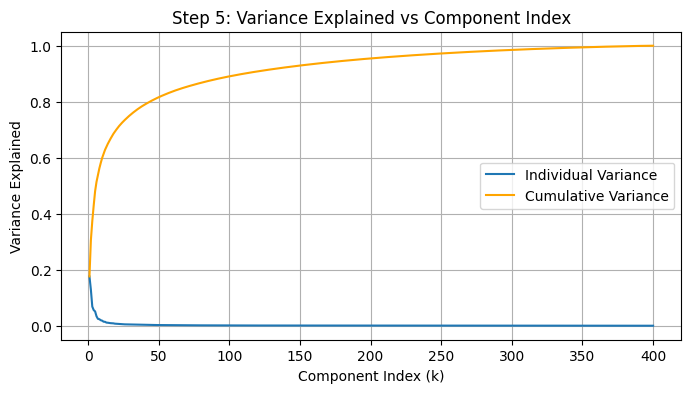

In [ ]:
# The eigenvalues represent the variance explained by each principal component
explained_variance = eigenvalues_S / np.sum(eigenvalues_S)
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 4))
plt.plot(range(1, D + 1), explained_variance, label='Individual Variance')
plt.plot(range(1, D + 1), cumulative_variance, label='Cumulative Variance', color='orange')
plt.xlabel('Component Index (k)')
plt.ylabel('Variance Explained')
plt.title('Step 5: Variance Explained vs Component Index')
plt.legend()
plt.grid(True)
plt.show()

**Low dimension Representation and Reconstruction Error and Plotting**

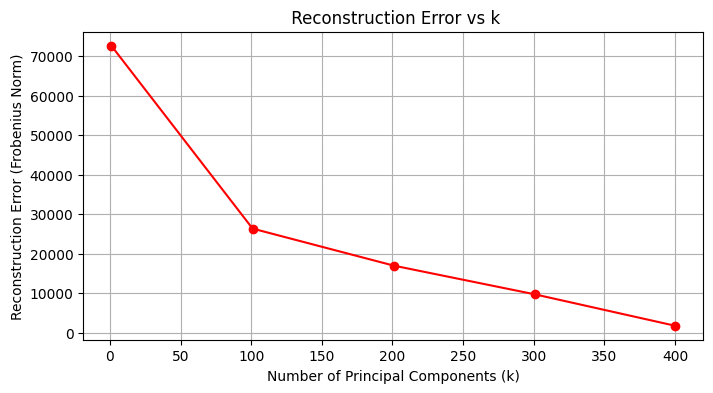

In [ ]:
k_values = list(range(1, D + 1, 100))
if D not in k_values:
    k_values.append(D)

reconstruction_errors = []

for k in k_values:
    # Use first k eigenvectors
    U_k = U[:, :k]

    # Low dimensional representation (k x 400)
    V_k = np.dot(U_k.T, X_centered)

    # Reconstructed data (10304 x 400) -> add mean face back
    X_hat = np.dot(U_k, V_k) + mean_face

    # Frobenius norm for reconstruction error
    error = np.linalg.norm(X - X_hat, ord='fro')
    reconstruction_errors.append(error)

plt.figure(figsize=(8, 4))
plt.plot(k_values, reconstruction_errors, marker='o', color='red')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Reconstruction Error (Frobenius Norm)')
plt.title(' Reconstruction Error vs k')
plt.grid(True)
plt.show()

From the reconstruction error plot, we observe that the error decreases rapidly as the number of principal components increases. After approximately k ≈ 100–200 components, the decrease in error becomes small and the curve stabilizes.

Therefore, selecting around 100–200 principal components provides a good balance between dimensionality reduction and reconstruction quality.

**Selecting Optimal k and Compare**

Optimal Settings
Selected Optimal k: 190 (Explains ~95% variance)
Reconstruction Error at k=190: 17841.64
Loss in Variance: 4.98%



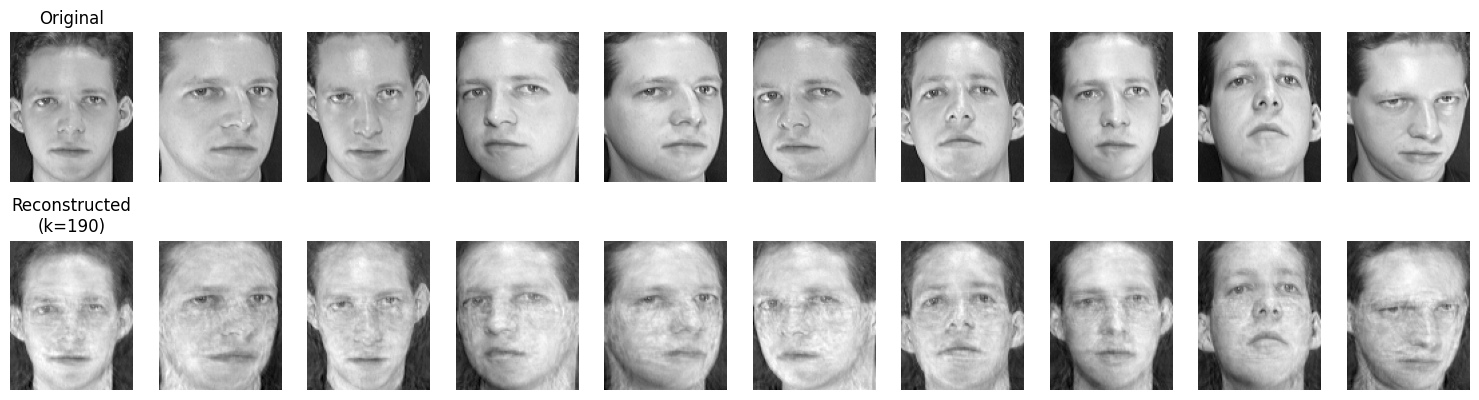

In [ ]:
# A common thought is choosing k that explains ~95% of the variance
optimal_k = np.argmax(cumulative_variance >= 0.95) + 1
loss_in_variance = 1 - cumulative_variance[optimal_k - 1]

U_opt = U[:, :optimal_k]
V_opt = np.dot(U_opt.T, X_centered)
X_hat_opt = np.dot(U_opt, V_opt) + mean_face
optimal_error = np.linalg.norm(X - X_hat_opt, ord='fro')

print(f"Optimal Settings")
print(f"Selected Optimal k: {optimal_k} (Explains ~95% variance)")
print(f"Reconstruction Error at k={optimal_k}: {optimal_error:.2f}")
print(f"Loss in Variance: {loss_in_variance * 100:.2f}%\n")

# Display 10 Original vs Reconstructed faces
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    # Original
    axes[0, i].imshow(X[:, i].reshape(112, 92), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original")

    # Reconstructed
    axes[1, i].imshow(X_hat_opt[:, i].reshape(112, 92), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title(f"\nReconstructed\n(k={optimal_k})")
plt.tight_layout()
plt.show()

# Acknowledgement

The assignment, with the help of language models/AI tools, is refined for better structuring of the code and diagrams. I have also used ISLP lab code/documentation and Google colab file shared by the course TA for reference.